# Product Demand Forecasting

## Business objective

This project forecasts the number of units sold each day for every `store_nbr` and product `family` in Kaggle's Store Sales - Time Series Forecasting competition. Reliable demand forecasts support inventory allocation, replenishment, staffing, and promotion planning. The target is `sales`; the competition test set is a 16-day forecast horizon.

This is a **time-series forecasting** task. Chronological order is preserved throughout: the latest 28 days are held out for validation, lag and rolling variables only use prior observations, and multi-step validation/test forecasts are recursive. The notebook investigates a seasonal-naive baseline, a global XGBoost model, SARIMA, and Prophet.

The dataset supplies promotions, holidays/events, store metadata, and oil prices. It does not provide advertising data, so no advertising feature is invented. Transaction counts are inspected but excluded from the forecasting model because they are unavailable for the complete future horizon.

## 1. Imports and configuration

Set `FAST_MODE=1` before executing from a terminal to run a smaller development experiment. The default (`FAST_MODE=0`) trains the practical global model on every series and produces a full XGBoost submission.

In [1]:
from pathlib import Path
import os
import random
import gc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor

try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid', context='notebook')

DATA_DIR = Path('data')
FAST_MODE = os.getenv('FAST_MODE', '0') == '1'
VALIDATION_DAYS = 28
SERIES_LIMIT = 120 if FAST_MODE else None
N_ESTIMATORS = 120 if FAST_MODE else 500
RUN_PROPHET = os.getenv('RUN_PROPHET', '1') == '1'
print(f'FAST_MODE={FAST_MODE}; validation window={VALIDATION_DAYS} days; Prophet available={HAS_PROPHET}')

Importing plotly failed. Interactive plots will not work.


FAST_MODE=True; validation window=28 days; Prophet available=True


## 2. Data loading

Place the seven competition CSV files directly in `data/`. Dates are parsed immediately so all subsequent joins and chronological checks use a proper datetime type.

In [2]:
required_files = ['train.csv', 'test.csv', 'stores.csv', 'transactions.csv', 'oil.csv', 'holidays_events.csv', 'sample_submission.csv']
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(
        f'Missing files in {DATA_DIR.resolve()}: {missing_files}. Download and extract the Kaggle competition archive first.'
    )

train = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['date'])
test = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['date'])
stores = pd.read_csv(DATA_DIR / 'stores.csv')
transactions = pd.read_csv(DATA_DIR / 'transactions.csv', parse_dates=['date'])
oil = pd.read_csv(DATA_DIR / 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(DATA_DIR / 'holidays_events.csv', parse_dates=['date'])
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

datasets = {
    'train': train, 'test': test, 'stores': stores, 'transactions': transactions,
    'oil': oil, 'holidays_events': holidays, 'sample_submission': sample_submission
}
overview = pd.DataFrame({
    'dataset': datasets.keys(),
    'shape': [frame.shape for frame in datasets.values()],
    'columns': [', '.join(frame.columns) for frame in datasets.values()]
})
display(overview)
for name, frame in datasets.items():
    print(f'\n{name.upper()} dtypes')
    display(frame.dtypes.to_frame('dtype').T)
    display(frame.head(3))

,dataset,shape,columns
0,train,"(3000888, 6)","id, date, store_nbr, family, sales, onpromotion"
1,test,"(28512, 5)","id, date, store_nbr, family, onpromotion"
2,stores,"(54, 5)","store_nbr, city, state, type, cluster"
3,transactions,"(83488, 3)","date, store_nbr, transactions"
4,oil,"(1218, 2)","date, dcoilwtico"
5,holidays_events,"(350, 6)","date, type, locale, locale_name, description, ..."
6,sample_submission,"(28512, 2)","id, sales"



TRAIN dtypes


,id,date,store_nbr,family,sales,onpromotion
dtype,int64,datetime64[us],int64,str,float64,int64


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0



TEST dtypes


...

,date,type,locale,locale_name,description,transferred
dtype,datetime64[us],str,str,str,str,bool


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False



SAMPLE_SUBMISSION dtypes


,id,sales
dtype,int64,float64


,id,sales
0,3000888,0.0
1,3000889,0.0
2,3000890,0.0


## 3. Data-quality analysis

Zero sales are retained: a zero can represent legitimate zero demand. Exact duplicate rows, missingness, invalid negative values, coverage, and descriptive statistics are audited before modeling. Oil values are not back-filled from future dates; missing oil observations remain missing or use only a past forward-fill later.

In [3]:
quality = pd.DataFrame({
    'rows': [len(frame) for frame in datasets.values()],
    'missing_cells': [int(frame.isna().sum().sum()) for frame in datasets.values()],
    'exact_duplicates': [int(frame.duplicated().sum()) for frame in datasets.values()]
}, index=datasets.keys())
display(quality)

print('Missing values by source column:')
for name, frame in datasets.items():
    missing = frame.isna().sum()
    missing = missing[missing.gt(0)]
    if not missing.empty:
        print(f'\n{name}:')
        display(missing.to_frame('missing_values'))

assert (train['sales'] >= 0).all(), 'Sales should not be negative.'
assert (train['onpromotion'] >= 0).all(), 'Promotion counts should not be negative.'
date_summary = pd.Series({
    'train_start': train['date'].min(),
    'train_end': train['date'].max(),
    'test_start': test['date'].min(),
    'test_end': test['date'].max(),
    'train_days': train['date'].nunique(),
    'test_days': test['date'].nunique(),
    'stores': train['store_nbr'].nunique(),
    'product_families': train['family'].nunique(),
    'zero_sales_share': train['sales'].eq(0).mean()
})
display(date_summary.to_frame('value'))
display(train[['sales', 'onpromotion']].describe(percentiles=[.01, .25, .5, .75, .99]).T)
print('Duplicate key rows:', train.duplicated(['date', 'store_nbr', 'family']).sum())
print('Zero sales are retained because they are valid observations, not automatically missing data.')

,rows,missing_cells,exact_duplicates
train,3000888,0,0
test,28512,0,0
stores,54,0,0
transactions,83488,0,0
oil,1218,43,0
holidays_events,350,0,0
sample_submission,28512,0,0


Missing values by source column:

oil:


,missing_values
dcoilwtico,43


,value
train_start,2013-01-01 00:00:00
train_end,2017-08-15 00:00:00
test_start,2017-08-16 00:00:00
test_end,2017-08-31 00:00:00
train_days,1684
test_days,16
stores,54
product_families,33
zero_sales_share,0.312951


,count,mean,std,min,1%,25%,50%,75%,99%,max
sales,3000888.0,357.775749,1101.997721,0.0,0.0,0.0,11.0,195.84725,5507.0,124717.0
onpromotion,3000888.0,2.602770,12.218882,0.0,0.0,0.0,0.0,0.00000,55.0,741.0


Duplicate key rows: 0
Zero sales are retained because they are valid observations, not automatically missing data.


## 4. Exploratory data analysis

The plots below describe trend, weekly and monthly patterns, concentration by store/family, the relationship between promotion status and sales, holiday effects, and oil-price context. Aggregation keeps the charts legible without changing the future modeling grain.

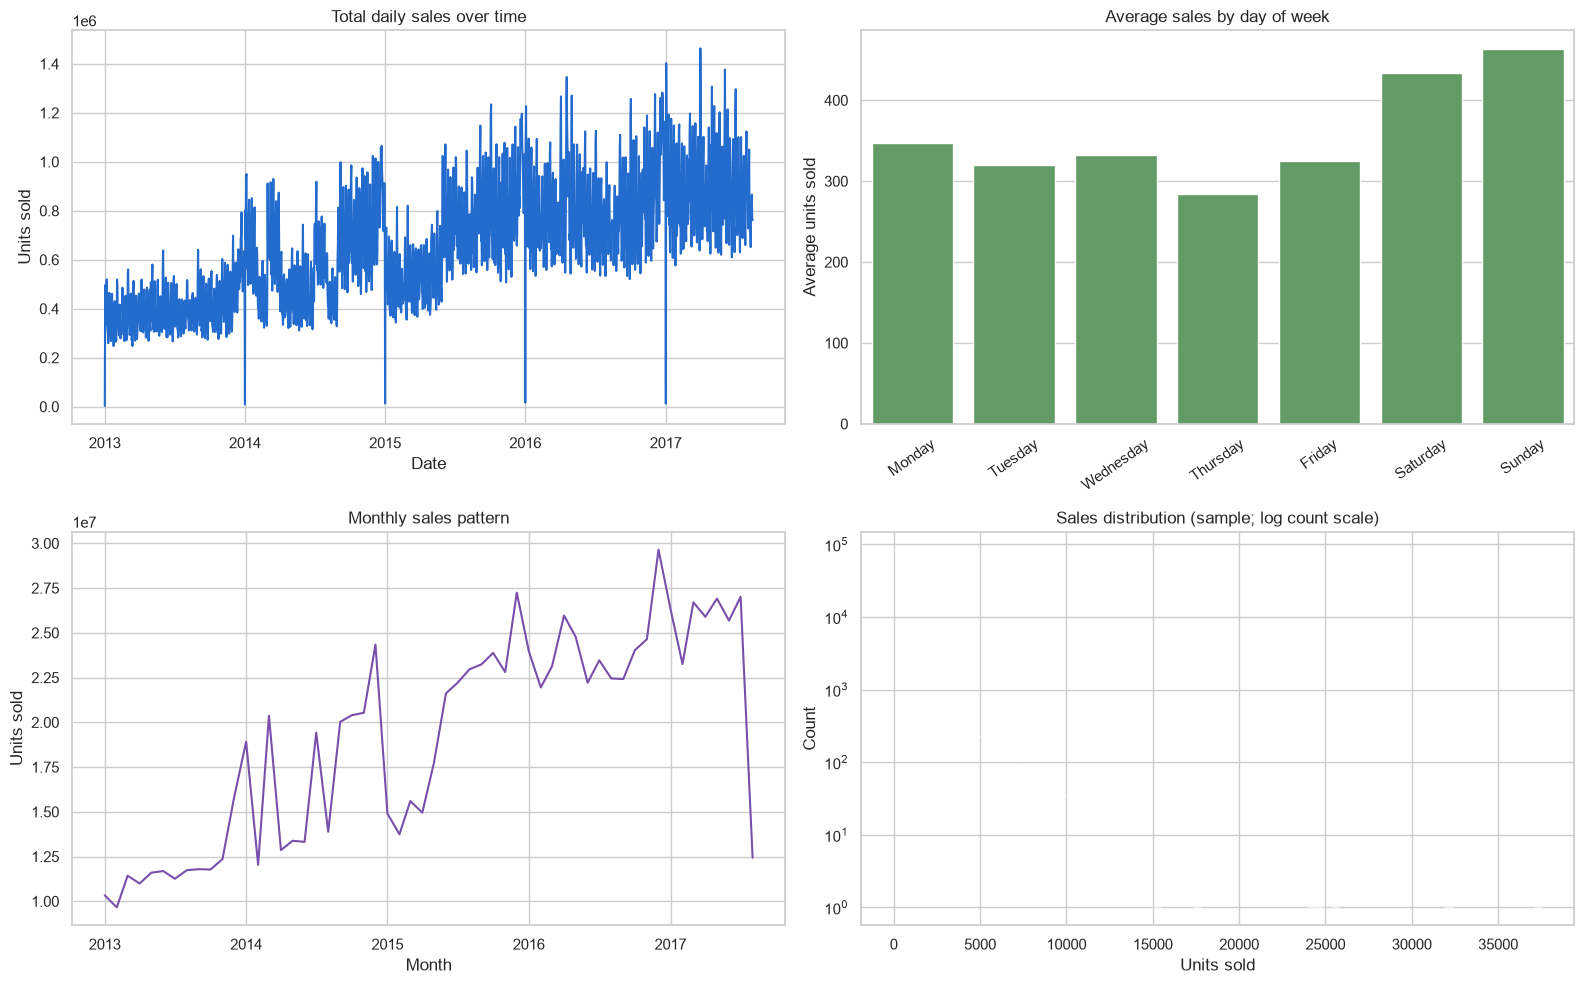

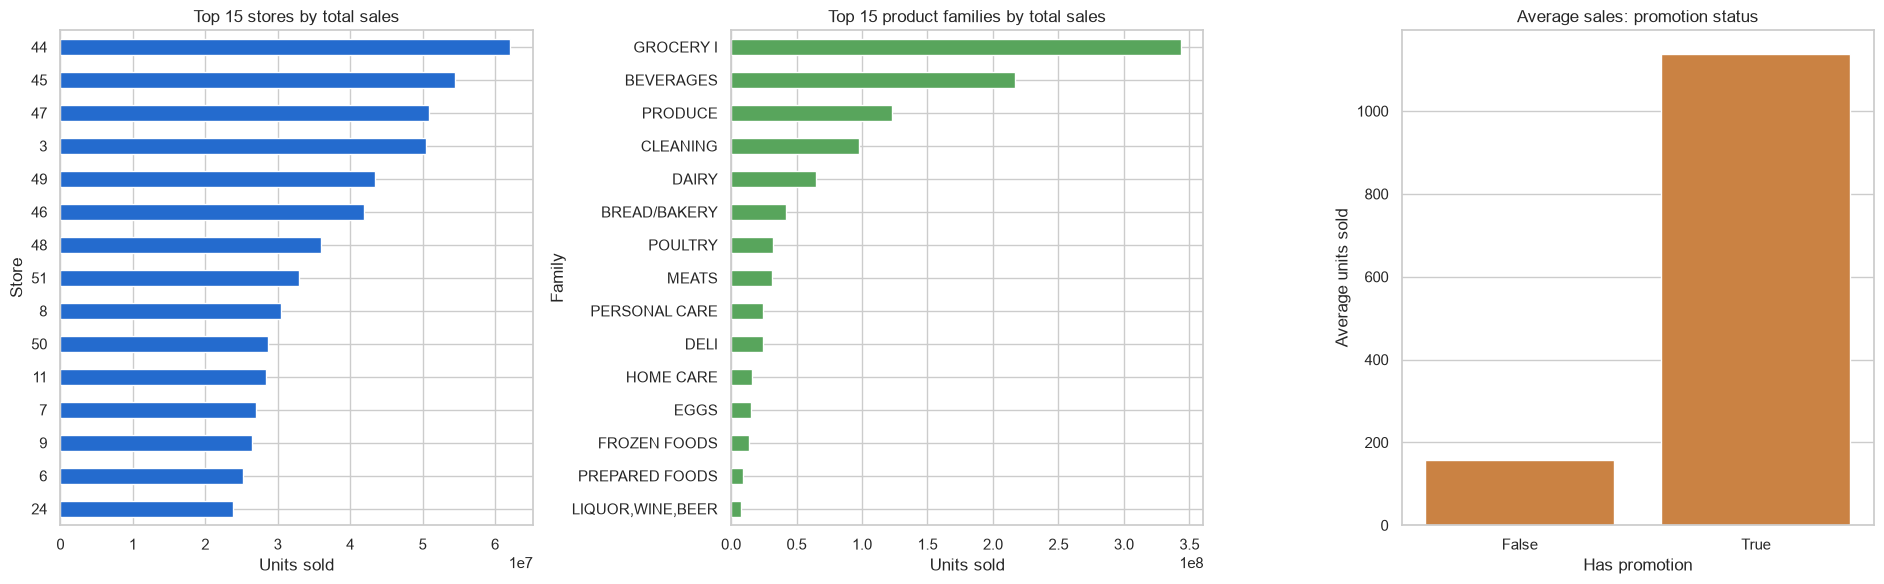

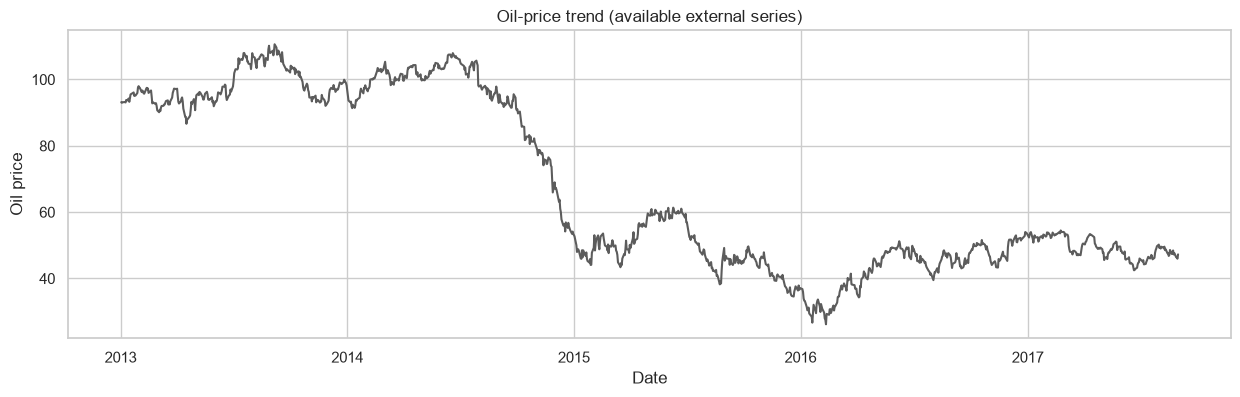

EDA interpretation should be based on the displayed aggregates. Promotion status is associated with sales, but this is descriptive rather than causal evidence.


In [4]:
daily_sales = train.groupby('date', as_index=False)['sales'].sum()
calendar_eda = train.assign(
    day_name=train['date'].dt.day_name(),
    month=train['date'].dt.month_name().str[:3],
    promoted=train['onpromotion'].gt(0)
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(data=daily_sales, x='date', y='sales', ax=axes[0, 0], color='#246BCE')
axes[0, 0].set(title='Total daily sales over time', xlabel='Date', ylabel='Units sold')
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = calendar_eda.groupby('day_name', as_index=False)['sales'].mean()
sns.barplot(data=dow_sales, x='day_name', y='sales', order=dow_order, ax=axes[0, 1], color='#58A55C')
axes[0, 1].tick_params(axis='x', rotation=35)
axes[0, 1].set(title='Average sales by day of week', xlabel='', ylabel='Average units sold')
monthly = train.groupby(train['date'].dt.to_period('M'))['sales'].sum().reset_index(name='sales')
monthly['date'] = monthly['date'].dt.to_timestamp()
sns.lineplot(data=monthly, x='date', y='sales', ax=axes[1, 0], color='#7A4EAB')
axes[1, 0].set(title='Monthly sales pattern', xlabel='Month', ylabel='Units sold')
plot_sample = train.sample(min(100_000, len(train)), random_state=RANDOM_STATE)
sns.histplot(data=plot_sample, x='sales', bins=80, log_scale=(False, True), ax=axes[1, 1], color='#E1812C')
axes[1, 1].set(title='Sales distribution (sample; log count scale)', xlabel='Units sold', ylabel='Count')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
top_stores = train.groupby('store_nbr')['sales'].sum().nlargest(15).sort_values()
top_stores.plot.barh(ax=axes[0], color='#246BCE')
axes[0].set(title='Top 15 stores by total sales', xlabel='Units sold', ylabel='Store')
top_families = train.groupby('family')['sales'].sum().nlargest(15).sort_values()
top_families.plot.barh(ax=axes[1], color='#58A55C')
axes[1].set(title='Top 15 product families by total sales', xlabel='Units sold', ylabel='Family')
promo_summary = calendar_eda.groupby('promoted', as_index=False)['sales'].mean()
sns.barplot(data=promo_summary, x='promoted', y='sales', ax=axes[2], color='#E1812C')
axes[2].set(title='Average sales: promotion status', xlabel='Has promotion', ylabel='Average units sold')
plt.tight_layout()
plt.show()

oil_plot = oil.sort_values('date').copy()
fig, ax = plt.subplots(figsize=(15, 4))
sns.lineplot(data=oil_plot, x='date', y='dcoilwtico', ax=ax, color='#5C5C5C')
ax.set(title='Oil-price trend (available external series)', xlabel='Date', ylabel='Oil price')
plt.show()
print('EDA interpretation should be based on the displayed aggregates. Promotion status is associated with sales, but this is descriptive rather than causal evidence.')

In [5]:
holiday_dates = holidays.loc[
    holidays['type'].isin(['Holiday', 'Additional', 'Bridge']) & ~holidays['transferred'], 'date'
].drop_duplicates()
holiday_eda = train.assign(is_holiday=train['date'].isin(holiday_dates))
holiday_summary = holiday_eda.groupby('is_holiday', as_index=False)['sales'].agg(['mean', 'median', 'count']).reset_index()
display(holiday_summary)
print('Holiday flags are later made store-aware for national, regional, and local entries.')

,index,is_holiday,mean,median,count
0,0,False,354.802942,11.0,2676564
1,1,True,382.309571,11.0,324324


Holiday flags are later made store-aware for national, regional, and local entries.


## 5. Time-series characteristics

A representative high-volume store-family series makes trend, variability, autocorrelation, and stationarity diagnostics interpretable. The production XGBoost model remains global across the store-family panel.

Representative series: store=44, family=GROCERY I


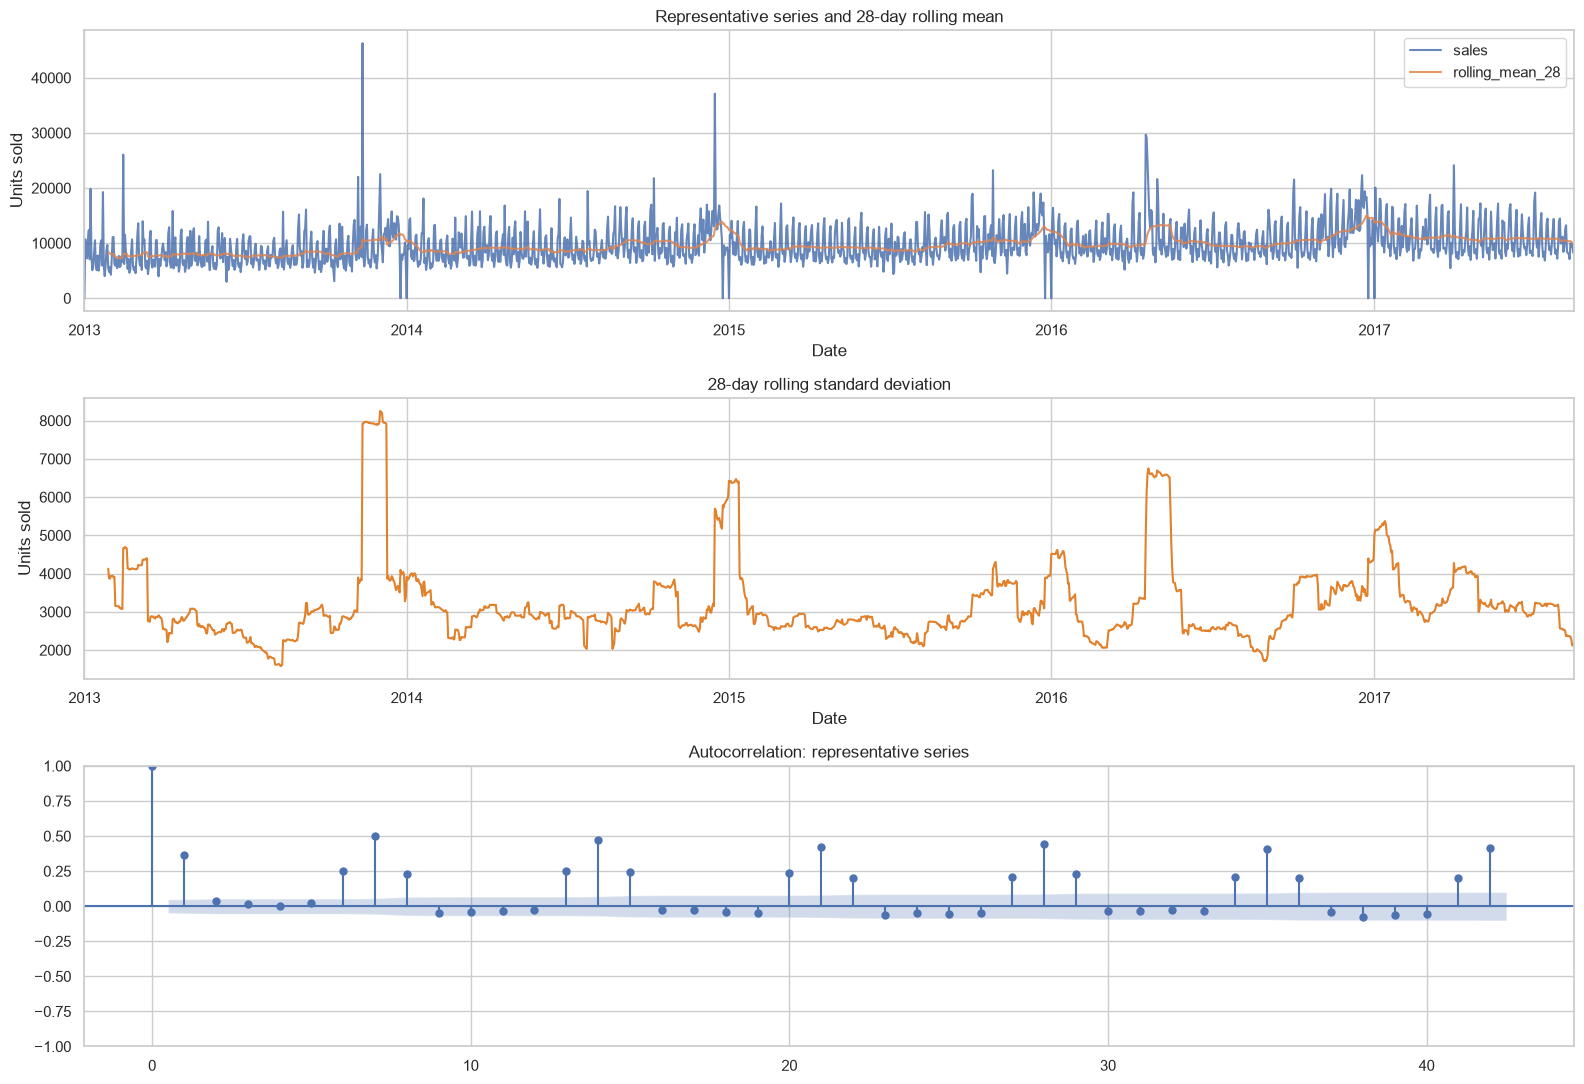

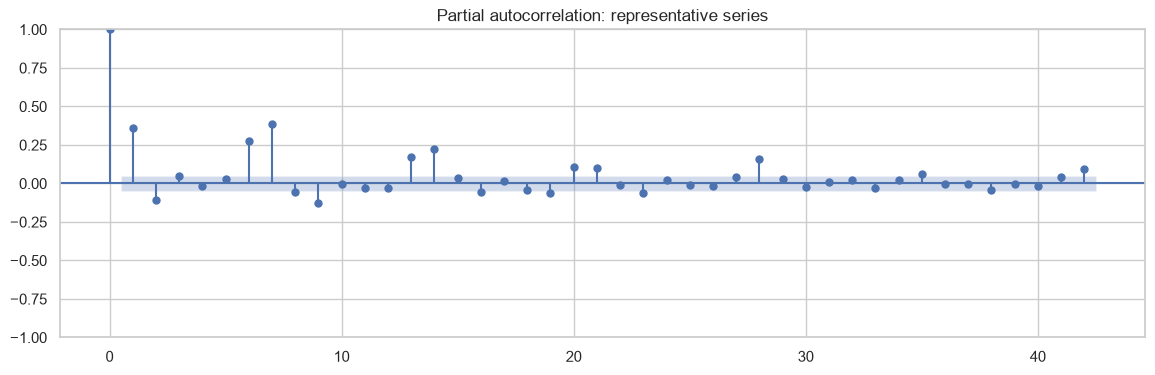

,ADF statistic,p-value
representative series,-5.013323,0.000021


A low ADF p-value supports stationarity after the tested transformation; seasonal structure can still require a seasonal model.


In [6]:
representative_store, representative_family = train.groupby(['store_nbr', 'family'])['sales'].sum().idxmax()
representative = train.loc[
    (train['store_nbr'].eq(representative_store)) & (train['family'].eq(representative_family)),
    ['date', 'sales']
].sort_values('date').set_index('date')['sales'].asfreq('D', fill_value=0)
print(f'Representative series: store={representative_store}, family={representative_family}')

rolling = pd.DataFrame({
    'sales': representative,
    'rolling_mean_28': representative.rolling(28).mean(),
    'rolling_std_28': representative.rolling(28).std(),
})
fig, axes = plt.subplots(3, 1, figsize=(16, 11))
rolling[['sales', 'rolling_mean_28']].plot(ax=axes[0], alpha=.85)
axes[0].set(title='Representative series and 28-day rolling mean', xlabel='Date', ylabel='Units sold')
rolling['rolling_std_28'].plot(ax=axes[1], color='#E1812C')
axes[1].set(title='28-day rolling standard deviation', xlabel='Date', ylabel='Units sold')
plot_acf(representative, lags=42, ax=axes[2])
axes[2].set_title('Autocorrelation: representative series')
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(14, 4))
plot_pacf(representative, lags=42, method='ywm', ax=ax)
ax.set_title('Partial autocorrelation: representative series')
plt.show()

adf_stat, adf_pvalue, *_ = adfuller(representative)
display(pd.DataFrame({'ADF statistic': [adf_stat], 'p-value': [adf_pvalue]}, index=['representative series']))
print('A low ADF p-value supports stationarity after the tested transformation; seasonal structure can still require a seasonal model.')

## 6. Feature engineering

Calendar, promotion, holiday, store, and oil features are joined at the known forecast grain. Lags and rolling statistics are built within each store-family series. Crucially, rolling windows use `shift(1)` first, preventing a current-day target from becoming its own input.

In [7]:
def add_store_aware_holidays(frame, holiday_frame):
    """Add holiday/event flags without treating a local holiday as national."""
    usable = holiday_frame.loc[~holiday_frame['transferred']].copy()
    usable['is_holiday_entry'] = usable['type'].isin(['Holiday', 'Additional', 'Bridge'])
    usable['is_event_entry'] = usable['type'].eq('Event')
    national = usable.loc[usable['locale'].eq('National')].groupby('date')[['is_holiday_entry', 'is_event_entry']].max()
    regional = usable.loc[usable['locale'].eq('Regional')].groupby(['date', 'locale_name'])[['is_holiday_entry', 'is_event_entry']].max()
    local = usable.loc[usable['locale'].eq('Local')].groupby(['date', 'locale_name'])[['is_holiday_entry', 'is_event_entry']].max()
    result = frame.copy()
    national_holiday = result['date'].map(national['is_holiday_entry']).fillna(False) if not national.empty else False
    national_event = result['date'].map(national['is_event_entry']).fillna(False) if not national.empty else False
    regional_holiday = result.set_index(['date', 'state']).index.map(regional['is_holiday_entry']).fillna(False) if not regional.empty else False
    regional_event = result.set_index(['date', 'state']).index.map(regional['is_event_entry']).fillna(False) if not regional.empty else False
    local_holiday = result.set_index(['date', 'city']).index.map(local['is_holiday_entry']).fillna(False) if not local.empty else False
    local_event = result.set_index(['date', 'city']).index.map(local['is_event_entry']).fillna(False) if not local.empty else False
    result['is_holiday'] = (pd.Series(national_holiday, index=result.index).astype(bool) | pd.Series(regional_holiday, index=result.index).astype(bool) | pd.Series(local_holiday, index=result.index).astype(bool)).astype('int8')
    result['is_event'] = (pd.Series(national_event, index=result.index).astype(bool) | pd.Series(regional_event, index=result.index).astype(bool) | pd.Series(local_event, index=result.index).astype(bool)).astype('int8')
    return result

def prepare_known_features(demand, stores_frame, oil_frame, holiday_frame):
    """Create features known from dates and supplied competition covariates."""
    result = demand.merge(stores_frame, on='store_nbr', how='left', validate='many_to_one').copy()
    oil_daily = oil_frame[['date', 'dcoilwtico']].sort_values('date').drop_duplicates('date').copy()
    oil_daily['oil_price'] = oil_daily['dcoilwtico'].ffill()  # never uses a later oil observation to fill an earlier date
    result = result.merge(oil_daily[['date', 'oil_price']], on='date', how='left', validate='many_to_one')
    result = add_store_aware_holidays(result, holiday_frame)
    result['year'] = result['date'].dt.year.astype('int16')
    result['month'] = result['date'].dt.month.astype('int8')
    result['day'] = result['date'].dt.day.astype('int8')
    result['day_of_week'] = result['date'].dt.dayofweek.astype('int8')
    result['week_of_year'] = result['date'].dt.isocalendar().week.astype('int16')
    result['quarter'] = result['date'].dt.quarter.astype('int8')
    result['is_weekend'] = result['day_of_week'].ge(5).astype('int8')
    result['is_month_start'] = result['date'].dt.is_month_start.astype('int8')
    result['is_month_end'] = result['date'].dt.is_month_end.astype('int8')
    result['series_id'] = result['store_nbr'].astype(str) + '__' + result['family'].astype(str)
    return result

# Fast mode limits only the materialized XGBoost history; EDA still uses all training rows.
if FAST_MODE:
    fast_pairs = train.groupby(['store_nbr', 'family'], as_index=False)['sales'].sum().nlargest(SERIES_LIMIT, 'sales')[['store_nbr', 'family']]
    train_for_features = train.merge(fast_pairs, on=['store_nbr', 'family'], how='inner', validate='many_to_one')
else:
    train_for_features = train
combined_base = pd.concat([train_for_features.assign(_source='train'), test.assign(sales=np.nan, _source='test')], ignore_index=True, sort=False)
prepared = prepare_known_features(combined_base, stores, oil, holidays)
for column in ['family', 'city', 'state', 'type']:
    prepared[f'{column}_code'] = pd.factorize(prepared[column], sort=True)[0].astype('int16')
prepared['cluster'] = prepared['cluster'].astype('int16')
train_known = prepared.loc[prepared['_source'].eq('train')].drop(columns=['_source', 'city', 'state', 'type']).copy()
test_known = prepared.loc[prepared['_source'].eq('test')].drop(columns=['_source', 'city', 'state', 'type']).copy()
for frame in (train_known, test_known):
    frame['family'] = frame['family'].astype('category')
    frame['series_id'] = frame['series_id'].astype('category')
    frame['onpromotion'] = frame['onpromotion'].astype('float32')
    frame['oil_price'] = frame['oil_price'].astype('float32')
    frame['id'] = frame['id'].astype('int32')
train_known['sales'] = train_known['sales'].astype('float32')
del prepared, combined_base, train_for_features
gc.collect()
expected_series = len(fast_pairs) if FAST_MODE else train.groupby(['store_nbr', 'family']).ngroups
assert train_known['series_id'].nunique() == expected_series
display(train_known.head())

,id,date,store_nbr,family,sales,onpromotion,cluster,oil_price,is_holiday,is_event,year,month,day,day_of_week,week_of_year,quarter,is_weekend,is_month_start,is_month_end,series_id,family_code,city_code,state_code,type_code
0,3,2013-01-01,1,BEVERAGES,0.0,0.0,13,NaN,1,0,2013,1,1,1,1,1,0,1,0,1__BEVERAGES,3,18,12,3
1,12,2013-01-01,1,GROCERY I,0.0,0.0,13,NaN,1,0,2013,1,1,1,1,1,0,1,0,1__GROCERY I,12,18,12,3
2,30,2013-01-01,1,PRODUCE,0.0,0.0,13,NaN,1,0,2013,1,1,1,1,1,0,1,0,1__PRODUCE,30,18,12,3
3,45,2013-01-01,10,GROCERY I,0.0,0.0,15,NaN,1,0,2013,1,1,1,1,1,0,1,0,10__GROCERY I,12,18,12,2
4,69,2013-01-01,11,BEVERAGES,0.0,0.0,6,NaN,1,0,2013,1,1,1,1,1,0,1,0,11__BEVERAGES,3,2,12,1


In [8]:
LAGS = [1, 7, 14, 28]
ROLLING_WINDOWS = [7, 14, 28]

def create_training_features(history):
    """Create leakage-safe lag/rolling variables for observed history only."""
    result = history.sort_values(['series_id', 'date']).copy()
    grouped_sales = result.groupby('series_id', sort=False)['sales']
    for lag in LAGS:
        result[f'lag_{lag}'] = grouped_sales.shift(lag)
    for window in ROLLING_WINDOWS:
        shifted = grouped_sales.transform(lambda values: values.shift(1))
        result[f'rolling_mean_{window}'] = shifted.groupby(result['series_id'], sort=False).transform(lambda values: values.rolling(window, min_periods=window).mean())
        result[f'rolling_std_{window}'] = shifted.groupby(result['series_id'], sort=False).transform(lambda values: values.rolling(window, min_periods=window).std())
    return result

BASE_FEATURES = [
    'store_nbr', 'family_code', 'city_code', 'state_code', 'type_code', 'cluster',
    'onpromotion', 'oil_price', 'is_holiday', 'is_event',
    'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter',
    'is_weekend', 'is_month_start', 'is_month_end'
]
DYNAMIC_FEATURES = [f'lag_{lag}' for lag in LAGS] + [f'rolling_mean_{window}' for window in ROLLING_WINDOWS] + [f'rolling_std_{window}' for window in ROLLING_WINDOWS]
FEATURE_COLUMNS = BASE_FEATURES + DYNAMIC_FEATURES
print('Model feature count:', len(FEATURE_COLUMNS))
print('Shifted rolling example:', 'sales.shift(1).rolling(7).mean()')

Model feature count: 29
Shifted rolling example: sales.shift(1).rolling(7).mean()


## 7. Leakage-safe chronological validation

The validation set is the latest 28 days, following all model-training observations. A random split would mix future and past patterns, permit unrealistically easy lag relationships, and misrepresent the real forecasting task. During recursive validation, actual sales inside this protected 28-day period are never supplied to the models.

In [9]:
all_train_dates = np.sort(train_known['date'].unique())
validation_start = pd.Timestamp(all_train_dates[-VALIDATION_DAYS])
validation_end = train_known['date'].max()
training_end = validation_start - pd.Timedelta(days=1)
print('Training period:', train_known['date'].min().date(), 'to', training_end.date())
print('Validation period:', validation_start.date(), 'to', validation_end.date())
print('Training period  ------------------------------>')
print('Validation period                               -------->')

series_rank = train_known.loc[train_known['date'].le(training_end)].groupby('series_id')['sales'].sum().sort_values(ascending=False)
selected_series = series_rank.index if SERIES_LIMIT is None else series_rank.head(SERIES_LIMIT).index
history_for_model = train_known.loc[train_known['date'].le(training_end) & train_known['series_id'].isin(selected_series)].copy()
validation_actual = train_known.loc[train_known['date'].ge(validation_start) & train_known['series_id'].isin(selected_series)].copy()
validation_known = validation_actual.drop(columns='sales')
print(f'Modeling {len(selected_series):,} series and {len(history_for_model):,} historical rows.')
if FAST_MODE:
    print('Development mode: validation metrics cover the selected high-volume series only; final predictions for other series use the seasonal-naive fallback.')

Training period: 2013-01-01 to 2017-07-18
Validation period: 2017-07-19 to 2017-08-15
Training period  ------------------------------>
Validation period                               -------->
Modeling 120 series and 198,720 historical rows.
Development mode: validation metrics cover the selected high-volume series only; final predictions for other series use the seasonal-naive fallback.


## 8. Recursive forecasting helpers and baseline

The helpers create forecast-date features from an evolving history. They implement the same information constraints for seasonal-naive, XGBoost validation, and the final test forecast. This is stricter than calculating validation lag features with known validation targets.

In [10]:
def add_dynamic_features_for_date(rows, observed_history, forecast_date):
    """Attach lags/rolls available just before one forecast date."""
    result = rows.copy()
    for lag in LAGS:
        values = observed_history.loc[observed_history['date'].eq(forecast_date - pd.Timedelta(days=lag)), ['series_id', 'sales']]
        result[f'lag_{lag}'] = result['series_id'].map(values.drop_duplicates('series_id').set_index('series_id')['sales']).astype('float32')
    for window in ROLLING_WINDOWS:
        window_start = forecast_date - pd.Timedelta(days=window)
        values = observed_history.loc[observed_history['date'].ge(window_start) & observed_history['date'].lt(forecast_date)].groupby('series_id')['sales']
        result[f'rolling_mean_{window}'] = result['series_id'].map(values.mean()).astype('float32')
        result[f'rolling_std_{window}'] = result['series_id'].map(values.std()).astype('float32')
    return result

def recursive_forecast(future_rows, observed_history, predictor):
    """Forecast each date in order; append predictions, never future actual targets."""
    state = observed_history[['series_id', 'date', 'sales']].copy()
    forecasts = []
    for forecast_date, date_rows in future_rows.sort_values('date').groupby('date', sort=True):
        features = add_dynamic_features_for_date(date_rows, state, forecast_date)
        prediction = np.clip(predictor(features), 0, None)
        step = date_rows[['id', 'date', 'store_nbr', 'family', 'series_id']].copy()
        step['prediction'] = prediction
        forecasts.append(step)
        state = pd.concat([state, step.rename(columns={'prediction': 'sales'})[['series_id', 'date', 'sales']]], ignore_index=True)
        state = state.loc[state['date'].ge(forecast_date - pd.Timedelta(days=max(ROLLING_WINDOWS) - 1))]
    return pd.concat(forecasts, ignore_index=True)

def seasonal_naive_predictor(features):
    fallback = features['rolling_mean_7'].fillna(features['lag_1']).fillna(0)
    return features['lag_7'].fillna(fallback).to_numpy()

def score_forecast(actual, prediction):
    actual = np.clip(np.asarray(actual, dtype=float), 0, None)
    prediction = np.clip(np.asarray(prediction, dtype=float), 0, None)
    return {
        'MAE': mean_absolute_error(actual, prediction),
        'RMSE': mean_squared_error(actual, prediction) ** 0.5,
        'RMSLE': mean_squared_log_error(actual, prediction) ** 0.5,
    }

baseline_validation = recursive_forecast(validation_known, history_for_model, seasonal_naive_predictor)
baseline_scored = validation_actual[['id', 'sales']].merge(baseline_validation[['id', 'prediction']], on='id', validate='one_to_one')
baseline_metrics = score_forecast(baseline_scored['sales'], baseline_scored['prediction'])
display(pd.DataFrame([{'Model': 'Seasonal naive (lag 7)', **baseline_metrics}]).round(4))

,Model,MAE,RMSE,RMSLE
0,Seasonal naive (lag 7),633.8331,1037.2018,0.2226


## 9. XGBoost global model

A single global gradient-boosted tree model learns from all selected store-family histories. It combines shifted demand history with known calendar and context variables. A limited, time-aware parameter choice is used instead of an expensive random cross-validation or exhaustive search.

Usable XGBoost training rows after 28-day history: 195,360


,MAE,RMSE,RMSLE
Model,,,
Seasonal naive (lag 7),633.8331,1037.2018,0.2226
XGBoost global model,470.0983,686.5453,0.1661


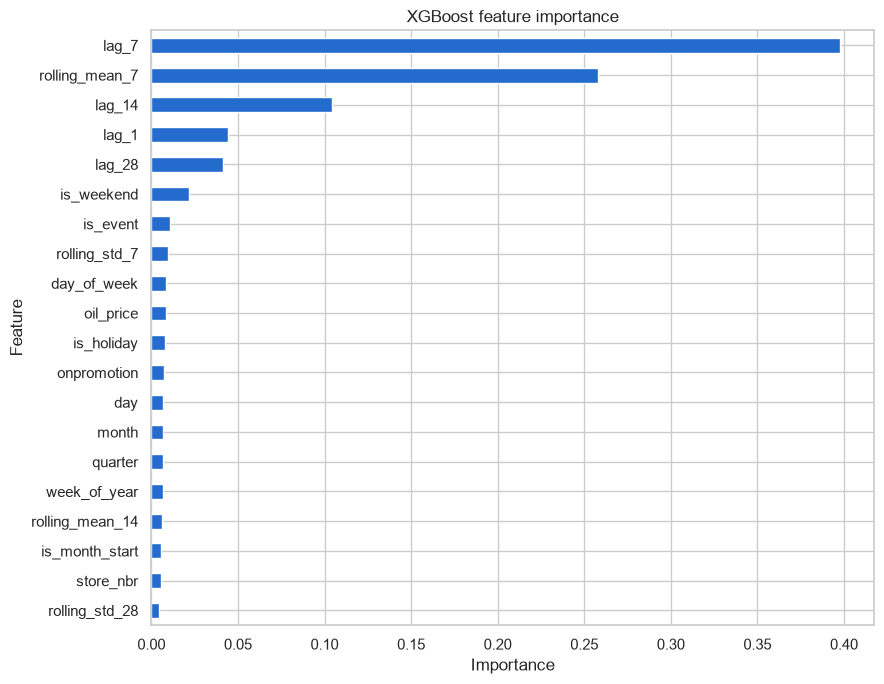

In [11]:
training_features = create_training_features(history_for_model)
model_training_rows = training_features.dropna(subset=[f'lag_{lag}' for lag in LAGS]).copy()
print(f'Usable XGBoost training rows after 28-day history: {len(model_training_rows):,}')

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=N_ESTIMATORS,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    tree_method='hist',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
xgb_model.fit(model_training_rows[FEATURE_COLUMNS], model_training_rows['sales'])

def xgb_predictor(features):
    return xgb_model.predict(features[FEATURE_COLUMNS])

xgb_validation = recursive_forecast(validation_known, history_for_model, xgb_predictor)
xgb_scored = validation_actual[['id', 'sales', 'store_nbr', 'family', 'date', 'onpromotion', 'is_holiday']].merge(
    xgb_validation[['id', 'prediction']], on='id', validate='one_to_one'
)
xgb_metrics = score_forecast(xgb_scored['sales'], xgb_scored['prediction'])
comparison = pd.DataFrame([
    {'Model': 'Seasonal naive (lag 7)', **baseline_metrics},
    {'Model': 'XGBoost global model', **xgb_metrics},
]).set_index('Model')
display(comparison.round(4))

importance = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
importance.sort_values().plot.barh(ax=ax, color='#246BCE')
ax.set(title='XGBoost feature importance', xlabel='Importance', ylabel='Feature')
plt.tight_layout()
plt.show()

## 10. SARIMA on aggregate demand

Fitting a separate ARIMA-family model to every store-family combination would require thousands of fits and is impractical for this notebook. SARIMA is therefore evaluated on aggregate daily demand. Its metrics are at a different grain from the store-family XGBoost metrics and must not be compared directly.

,Aggregate model,MAE,RMSE,RMSLE
0,"SARIMA(1,1,1)x(1,0,1,7)",62822.0619,92918.8539,0.105


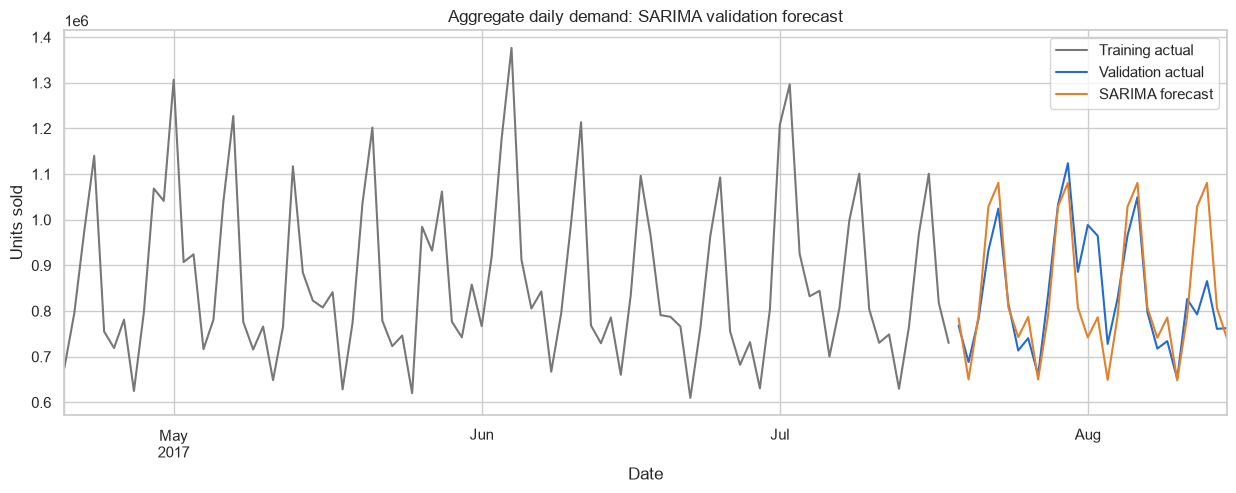

In [12]:
aggregate_train = daily_sales.set_index('date')['sales'].asfreq('D', fill_value=0)
aggregate_fit = aggregate_train.loc[:training_end]
aggregate_validation = aggregate_train.loc[validation_start:validation_end]
sarima_model = SARIMAX(
    aggregate_fit, order=(1, 1, 1), seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False, enforce_invertibility=False
)
sarima_result = sarima_model.fit(disp=False)
sarima_prediction = np.clip(sarima_result.get_forecast(steps=len(aggregate_validation)).predicted_mean, 0, None)
sarima_metrics = score_forecast(aggregate_validation, sarima_prediction)
display(pd.DataFrame([{'Aggregate model': 'SARIMA(1,1,1)x(1,0,1,7)', **sarima_metrics}]).round(4))
fig, ax = plt.subplots(figsize=(15, 5))
aggregate_fit.tail(90).plot(ax=ax, label='Training actual', color='#777777')
aggregate_validation.plot(ax=ax, label='Validation actual', color='#246BCE')
pd.Series(sarima_prediction, index=aggregate_validation.index).plot(ax=ax, label='SARIMA forecast', color='#E1812C')
ax.set(title='Aggregate daily demand: SARIMA validation forecast', xlabel='Date', ylabel='Units sold')
ax.legend()
plt.show()

## 11. Prophet on aggregate demand

Prophet is also demonstrated on aggregate demand to avoid blindly maintaining thousands of individual models. The national holiday calendar is known in advance; local and regional holiday effects are already handled in the granular XGBoost features. If Prophet is unavailable in an environment, install `requirements.txt` and re-run this cell.

16:06:48 - cmdstanpy - INFO - Chain [1] start processing


16:06:48 - cmdstanpy - INFO - Chain [1] done processing


,Aggregate model,MAE,RMSE,RMSLE
0,Prophet,71675.2157,88601.0149,0.1042


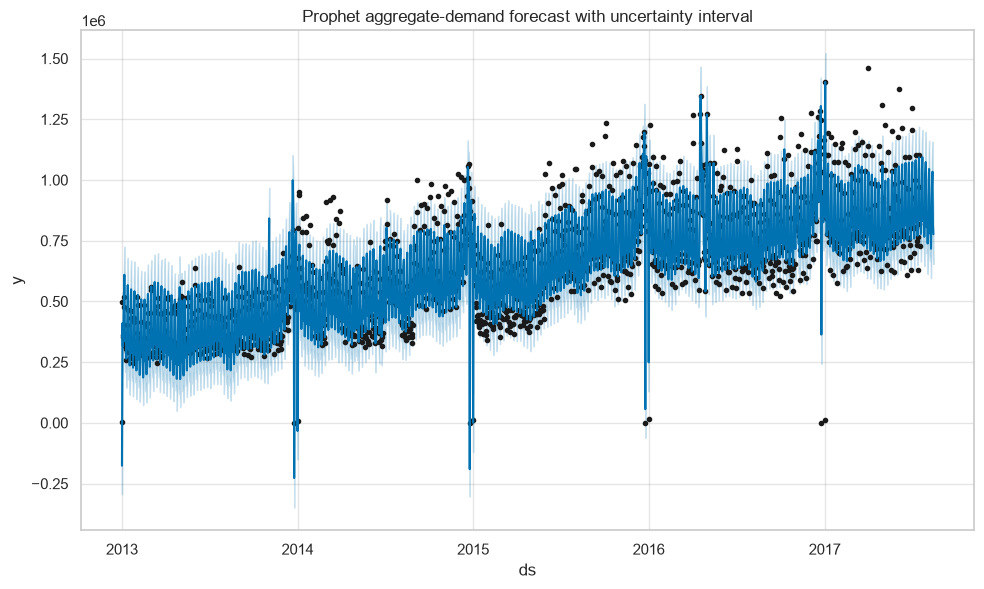

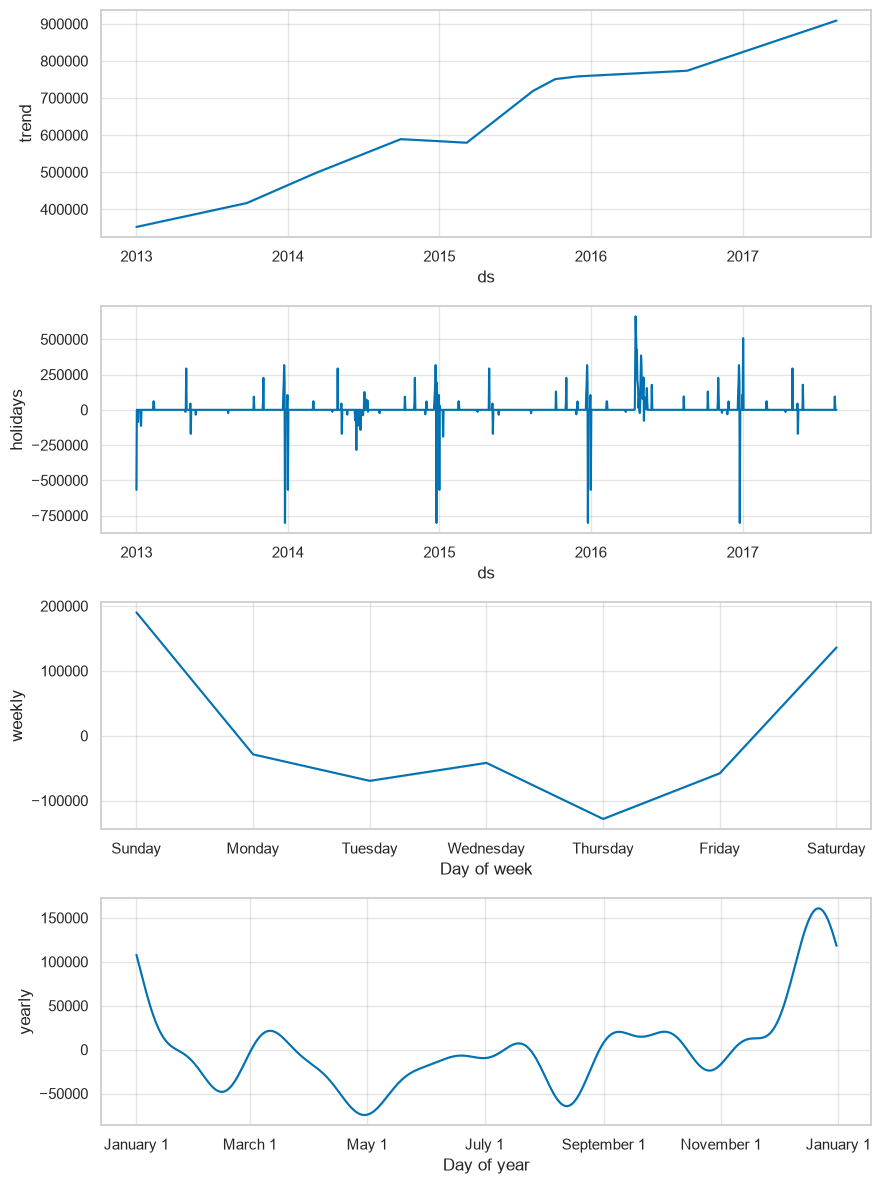

In [13]:
prophet_metrics = None
if HAS_PROPHET and RUN_PROPHET:
    prophet_holidays = holidays.loc[
        holidays['locale'].eq('National') & ~holidays['transferred'], ['date', 'description']
    ].drop_duplicates().rename(columns={'date': 'ds', 'description': 'holiday'})
    prophet_train = aggregate_fit.rename_axis('ds').reset_index(name='y')
    prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False, holidays=prophet_holidays)
    prophet_model.fit(prophet_train)
    prophet_future = prophet_model.make_future_dataframe(periods=len(aggregate_validation), freq='D')
    prophet_forecast = prophet_model.predict(prophet_future)
    prophet_validation = prophet_forecast.set_index('ds').loc[aggregate_validation.index, 'yhat'].clip(lower=0)
    prophet_metrics = score_forecast(aggregate_validation, prophet_validation)
    display(pd.DataFrame([{'Aggregate model': 'Prophet', **prophet_metrics}]).round(4))
    fig = prophet_model.plot(prophet_forecast)
    plt.title('Prophet aggregate-demand forecast with uncertainty interval')
    plt.show()
    fig = prophet_model.plot_components(prophet_forecast)
    plt.show()
else:
    print('Prophet is unavailable or disabled. Install requirements and set RUN_PROPHET=1 to run this aggregate demonstration.')

## 12. Evaluation, forecast visualization, and error analysis

MAE measures average absolute unit error; RMSE emphasizes large misses; RMSLE evaluates relative error after a log transform and requires non-negative predictions. MAPE is not a primary metric because legitimate zero-sales days make percentages undefined or unstable.

Store-family-day comparison (directly comparable):


,MAE,RMSE,RMSLE
Model,,,
Seasonal naive (lag 7),633.8331,1037.2018,0.2226
XGBoost global model,470.0983,686.5453,0.1661


Aggregate daily comparison (separate forecasting grain):


,MAE,RMSE,RMSLE
Model,,,
SARIMA,62822.0619,92918.8539,0.1050
Prophet,71675.2157,88601.0149,0.1042


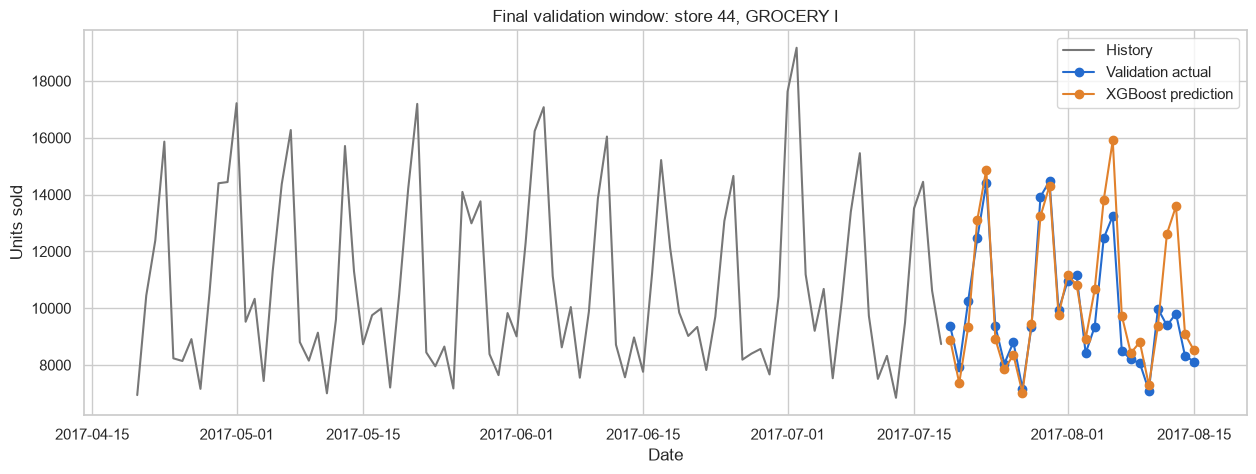

Families with the highest validation MAE:


,MAE,RMSE,rows
family,,,
BEVERAGES,592.492981,826.560974,980
GROCERY I,491.316986,715.213989,1428
PRODUCE,354.734985,499.782013,476
CLEANING,301.117004,406.274994,308
DAIRY,212.434998,288.457001,168


Stores with the highest validation MAE:


,MAE,RMSE,rows
store_nbr,,,
40,1003.409973,1458.267944,56
38,783.289978,1046.803955,56
28,764.328003,1237.527954,56
20,751.445007,977.278015,56
39,745.132019,892.942993,56
41,687.570007,865.401001,56
36,678.606018,877.638977,56
44,655.315002,967.099976,140
46,589.328003,829.646973,112


Validation error by holiday and promotion context:


MAE        RMSE  rows
is_holiday is_promoted                              
0          False        454.319000  678.661987    14
           True         470.657990  687.633972  3308
1          True         427.170013  587.426025    38

High-error cases often combine intermittent demand, spikes, holidays, or promotions. Inspect the tables rather than assuming one universal source of error.


In [14]:
aggregate_comparison = pd.DataFrame([{'Model': 'SARIMA', **sarima_metrics}])
if prophet_metrics is not None:
    aggregate_comparison = pd.concat([aggregate_comparison, pd.DataFrame([{'Model': 'Prophet', **prophet_metrics}])], ignore_index=True)
print('Store-family-day comparison (directly comparable):')
display(comparison.round(4))
print('Aggregate daily comparison (separate forecasting grain):')
display(aggregate_comparison.set_index('Model').round(4))

representative_validation = xgb_scored.loc[
    xgb_scored['store_nbr'].eq(representative_store) & xgb_scored['family'].eq(representative_family)
].sort_values('date')
representative_history = history_for_model.loc[
    history_for_model['store_nbr'].eq(representative_store) & history_for_model['family'].eq(representative_family)
].sort_values('date').tail(90)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(representative_history['date'], representative_history['sales'], label='History', color='#777777')
ax.plot(representative_validation['date'], representative_validation['sales'], label='Validation actual', marker='o', color='#246BCE')
ax.plot(representative_validation['date'], representative_validation['prediction'], label='XGBoost prediction', marker='o', color='#E1812C')
ax.set(title=f'Final validation window: store {representative_store}, {representative_family}', xlabel='Date', ylabel='Units sold')
ax.legend()
plt.show()

xgb_scored['absolute_error'] = (xgb_scored['sales'] - xgb_scored['prediction']).abs()
xgb_scored['squared_error'] = (xgb_scored['sales'] - xgb_scored['prediction']).pow(2)
family_errors = xgb_scored.groupby('family').agg(MAE=('absolute_error', 'mean'), RMSE=('squared_error', lambda x: np.sqrt(x.mean())), rows=('sales', 'size')).sort_values('MAE', ascending=False).head(12)
store_errors = xgb_scored.groupby('store_nbr').agg(MAE=('absolute_error', 'mean'), RMSE=('squared_error', lambda x: np.sqrt(x.mean())), rows=('sales', 'size')).sort_values('MAE', ascending=False).head(12)
context_errors = xgb_scored.assign(is_promoted=xgb_scored['onpromotion'].gt(0)).groupby(['is_holiday', 'is_promoted']).agg(MAE=('absolute_error', 'mean'), RMSE=('squared_error', lambda x: np.sqrt(x.mean())), rows=('sales', 'size'))
print('Families with the highest validation MAE:')
display(family_errors.round(3))
print('Stores with the highest validation MAE:')
display(store_errors.round(3))
print('Validation error by holiday and promotion context:')
display(context_errors.round(3))
print('High-error cases often combine intermittent demand, spikes, holidays, or promotions. Inspect the tables rather than assuming one universal source of error.')

## 13. Final test-horizon forecast and Kaggle submission

The selected XGBoost model is refit using all available pre-test history and recursively forecasts the supplied 16-day test dates. Predictions are aligned by `id`, clipped to zero, checked for completeness, and saved as `submission.csv`. In full mode this is a global XGBoost forecast for every series; development mode documents its seasonal-naive fallback for unselected series.

In [15]:
# The validation fit is no longer needed; release it before the final refit.
del training_features, model_training_rows, xgb_model
gc.collect()
final_history = train_known.loc[train_known['series_id'].isin(selected_series)].copy()
final_training_features = create_training_features(final_history)
final_model_rows = final_training_features.dropna(subset=[f'lag_{lag}' for lag in LAGS]).copy()
final_xgb_model = XGBRegressor(
    objective='reg:squarederror', n_estimators=N_ESTIMATORS, learning_rate=0.05, max_depth=8,
    min_child_weight=8, subsample=0.85, colsample_bytree=0.85, reg_lambda=1.0,
    tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE
)
final_xgb_model.fit(final_model_rows[FEATURE_COLUMNS], final_model_rows['sales'])
del final_training_features, final_model_rows
gc.collect()

def final_xgb_predictor(features):
    return final_xgb_model.predict(features[FEATURE_COLUMNS])

selected_test = test_known.loc[test_known['series_id'].isin(selected_series)].copy()
xgb_test_forecast = recursive_forecast(selected_test, final_history, final_xgb_predictor)
if FAST_MODE:
    fallback_test = test_known.loc[~test_known['series_id'].isin(selected_series)].copy()
    fallback_history = train[['date', 'store_nbr', 'family', 'sales']].copy()
    fallback_history['series_id'] = fallback_history['store_nbr'].astype(str) + '__' + fallback_history['family'].astype(str)
    fallback_forecast = recursive_forecast(fallback_test, fallback_history, seasonal_naive_predictor)
    final_predictions = pd.concat([xgb_test_forecast, fallback_forecast], ignore_index=True)
else:
    final_predictions = xgb_test_forecast

submission = sample_submission[['id']].merge(final_predictions[['id', 'prediction']], on='id', how='left', validate='one_to_one')
submission = submission.rename(columns={'prediction': 'sales'})
assert len(submission) == len(test), 'Submission row count differs from test data.'
assert submission['id'].is_unique, 'Submission ids must be unique.'
assert submission['sales'].notna().all(), 'Some test rows did not receive a prediction.'
submission['sales'] = submission['sales'].clip(lower=0)
submission.to_csv('submission.csv', index=False)
display(submission.head())
print(f'Wrote {len(submission):,} non-negative predictions to {Path("submission.csv").resolve()}.')

,id,sales
0,3000888,7.00000
1,3000889,0.00000
2,3000890,4.00000
3,3000891,2212.54126
4,3000892,0.00000


Wrote 28,512 non-negative predictions to D:\Admin\Coding\ml\pet-project4\submission.csv.


## 14. Conclusions

This notebook measures the conclusions from the generated tables and plots rather than inventing scores. Daily retail demand usually shows trend and weekly structure, while promotions, calendar events, and product/store heterogeneity can create peaks that a simple weekly baseline misses. Shifted lags and rolling features give the global model its historical context without target leakage.

The XGBoost-versus-baseline table identifies the strongest practical store-family forecasting approach for this run. SARIMA and Prophet provide useful aggregate-level time-series perspectives but are not presented as directly comparable to the granular model. Limitations include recursive error accumulation, unobserved disruptions, data coverage, and a global model's inability to represent every series perfectly. Possible next steps are CatBoost or LightGBM, store/family-specific or hierarchical models, probabilistic forecasts, carefully time-aware tuning, ensembles, and additional genuinely available external data.